# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_GROWTH_SURPRISE_CRASH_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

print(f"Data loaded: {df.shape}")
print(f"Years: {df['date'].unique().min()}")
print(f"Years: {df['date'].unique().max()}")


2026-03-21 12:36:56.544 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/21 12:36:57 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/21 12:36:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-64af84b0-8d81-42ff-ba42-8e89bb0187a5;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central


:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 68ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-64af84b0-8d81-42ff-ba42-8e89bb0187a5
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/2ms)
26/03/21 12:36:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-ja

Spark Session created.


Data loaded: (547524, 166)
Years: 1990-01-05 00:00:00
Years: 2026-03-18 00:00:00


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,vix_vix3m_ratio,priceToGrahamNumber,ncavToMarketCap,cashYield,workingCapitalToMarketCap,log_marketCap,log_enterpriseValue,year,month,week
count,547524,547524.000000,5.475240e+05,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,...,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000,547524.000000
mean,2013-10-17 16:09:24.139654400,80.124923,8.482395e+06,0.000397,0.000083,-0.008824,-0.006151,-0.021748,-0.003477,0.000588,...,1.267721,4.935991,1.115121,0.342671,1.446063,23.667589,23.924716,2013.293182,6.548276,3.962108
min,1990-01-05 00:00:00,0.061792,3.500000e+01,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,0.414363,0.005698,-461.961802,-213.218614,-461.774535,16.151062,15.934341,1990.000000,1.000000,0.000000
25%,2007-05-25 00:00:00,17.650000,1.148300e+06,-0.004662,0.000004,-0.509554,-0.505882,-0.523549,-0.502326,-0.497942,...,1.051585,1.468213,-0.736505,0.028742,-0.009757,22.918546,23.160771,2007.000000,4.000000,4.000000
50%,2014-10-10 00:00:00,35.960000,2.491100e+06,0.000838,0.000060,-0.011719,-0.008850,-0.028571,-0.004484,0.000000,...,1.247377,2.516002,-0.246506,0.073268,0.048719,23.581455,23.821307,2014.000000,7.000000,4.000000
75%,2020-10-16 00:00:00,80.020000,5.640258e+06,0.005757,0.000172,0.489231,0.492308,0.475345,0.494624,0.499006,...,1.444664,4.407182,-0.041555,0.181073,0.139311,24.404261,24.624767,2020.000000,10.000000,4.000000
max,2026-03-18 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.750128,598.616665,23191.277706,110.197651,20386.838437,29.169688,29.169546,2026.000000,12.000000,4.000000
std,NaN,213.755207,5.017140e+07,0.011162,0.000082,0.577738,0.577264,0.575771,0.576836,0.576832,...,0.320712,15.111710,167.019498,1.424820,130.241898,1.269436,1.251022,8.122117,3.460652,0.215312


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
import pandas as pd
import numpy as np

def create_alpha_target(df, period='1YE', top_n=50, min_return=0.30):
    """
    Crée une cible de classification basée sur un rendement absolu minimum.
    Cible = 1 SI l'action fait au moins `min_return` (ex: +30%) 
              ET SI elle fait partie des `top_n` meilleures actions de cette période.
    """
    df = df.copy()
    
    # --- 0. S'assurer des formats et du tri initial ---
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # --- 1. Calculer le rendement futur brut ---
    target = df.groupby(['symbol', pd.Grouper(key='date', freq=period)])['adjClose'].last().reset_index()
    
    # Calcul du rendement de la période (ex: sur 1 an)
    target['future_return'] = target.groupby('symbol')['adjClose'].shift(-1) / target['adjClose'] - 1
    
    # --- 2. Classement Transversal (Qui sont les meilleurs ?) ---
    # On classe du meilleur rendement (rang 1) au pire
    target['rank_cross_sectional'] = target.groupby('date')['future_return'].rank(method='first', ascending=False)
    
    # --- 3. Création de la cible (Classification) ---
    # Condition 1 : L'action doit battre ton seuil absolu (ex: 30%)
    cond_absolute_return = target['future_return'] >= min_return
    
    # Condition 2 : L'action doit être dans le Top N pour qu'on ne garde que l'élite
    cond_top_n = target['rank_cross_sectional'] <= top_n
    
    # L'action reçoit un 1 UNIQUEMENT si elle explose le seuil ET qu'elle est parmi les meilleures
    target['target_y'] = (cond_absolute_return & cond_top_n).astype(int)
    
    # --- 4. Nettoyage et fusion avec le dataset final ---
    target = target[['symbol', 'date', 'target_y']]

    df = df.sort_values(by='date')
    target = target.sort_values(by='date')
    
    df = pd.merge_asof(
        df,
        target,
        on='date',
        by='symbol',
        direction='forward'
    )

    df['target_y'] = df['target_y'].fillna(0).astype(int)
    
    # Petit reporting de contrôle pour toi
    print(f"📊 Pourcentage global de '1' (Cibles atteintes) : {(df['target_y'].mean() * 100):.2f}%")
    
    return df

# Exécution de la fonction : 
# Exemple pour une période de 1 an avec un objectif de +30% minimum sur le Top 50
df = create_alpha_target(df, period='1YE', top_n=50, min_return=0.30)

📊 Pourcentage global de '1' (Cibles atteintes) : 11.49%


In [5]:
df['target_y'].value_counts()

target_y
0    484610
1     62914
Name: count, dtype: int64

## 4. Algorithm Model Architectures

In [6]:
"""
colonne_list = df.columns.tolist()
colonnes_texte = df.select_dtypes(exclude=['number']).columns.tolist()
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'workingCapital', 'investedCapital', 'grahamNumber', 'target_y']
features = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)
features = list(features)
print("features :", features)
"""

'\ncolonne_list = df.columns.tolist()\ncolonnes_texte = df.select_dtypes(exclude=[\'number\']).columns.tolist()\ncolonnes_biais = [\'date\', \'volume\', \'adjClose\',\'symbol\', \'workingCapital\', \'investedCapital\', \'grahamNumber\', \'target_y\']\nfeatures = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)\nfeatures = list(features)\nprint("features :", features)\n'

In [7]:
Value = ['priceToBookRatio', 'priceToSalesRatio', 'priceToFreeCashFlowRatio', 'evToEBITDA', 'cashYield']
Quality = ['returnOnInvestedCapital', 'grossProfitMargin', 'interestCoverageRatio', 'freeCashFlowOperatingCashFlowRatio', 'currentRatio']
Growth = ['tenYRevenueGrowthPerShare', 'threeYOperatingCFGrowthPerShare', 'netIncomeGrowth', 'fiveYDividendperShareGrowthPerShare', 'suprise_eps']
Momentum = ['mom6m', 'mom12m', 'high52', 'retvol', 'dist_ma25']
Macro = ['market_return', 'risk_free_rate', 'vix3m']
colonnes_biais = [
    'date', 
    'volume', 
    'adjClose',
    'symbol',  
    'target_y', 
    'year', 
    'adjClose_GSPC', 
    'volume_GSPC',
    'marketCap',
    'enterpriseValue'
    ]
reduce_features = [
    'bear_market_ma',
    'enterpriseValueMultiple',
    'bottomLineProfitMargin',
    'weightedAverageSharesGrowth',
    'epsgrowth',
    'capexToOperatingCashFlow',
    'operatingProfitMargin',
    'ebitMargin',
    'returnOnAssets',
    'returnOnTangibleAssets',
    'debtToAssetsRatio',
    'assetTurnover',
    'solvencyRatio',
    'inventoryTurnover',
    'evToFreeCashFlow',
    'priceToFreeCashFlowRatio',
    'operatingCycle',
    'daysOfInventoryOutstanding',
    'inventoryGrowth',
    'quickRatio',
    'pretaxProfitMargin',
    'continuousOperationsProfitMargin',
    'ebitdaMargin',
    'evToSales',
    'operatingCashFlowSalesRatio',
    'salesGeneralAndAdministrativeToRevenue',
    'evToOperatingCashFlow',
    'netDebtToEBITDA',
    'log_enterpriseValue',
    'debtServiceCoverageRatio',
    'financialLeverageRatio',
    'threeYDividendperShareGrowthPerShare',
    'tenYBottomLineNetIncomeGrowthPerShare',
    'netIncomePerEBT',
    'workingCapitalToMarketCap',
    'epsActual',
    'epsEstimated',
    'dist_ma25',
    'netProfitMargin',
    'taxBurden',
    'priceToOperatingCashFlowRatio',
    'dist_ma50',
    'dist_ma12',
    'vix',
    'threeYShareholdersEquityGrowthPerShare',
    'tenYDividendperShareGrowthPerShare',
    'dividendPerShare',
    'log_marketCap',
    'log_enterpriseValue',
    'revenueActual',
    'revenueEstimated',
    'intangiblesToTotalAssets',
    'vix3m',
    'vix',
    'risk_free_rate',
    'bull_market_ma',
    'vix_vix3m_ratio'

 ]
#reduce_features = []

#colunms = df.columns.tolist()
#string_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
#print("Colonnes de type texte :", string_cols)

# 2. Ta logique d'ensembles (sets) était parfaite, on la garde !
# J'ai juste simplifié la soustraction pour que ce soit plus lisible
#features = list((set(colunms)) - (set(colonnes_biais) | set(string_cols)))
#features = list((set(colunms)) - (set(colonnes_biais) | set(reduce_features) | set(string_cols)))
features = Value + Quality + Growth + Momentum + Macro

print("Nombre de features conservées :", len(features))
# print("features :", features)


Nombre de features conservées : 23


In [9]:
df[features]

,priceToBookRatio,priceToSalesRatio,priceToFreeCashFlowRatio,evToEBITDA,cashYield,returnOnInvestedCapital,grossProfitMargin,interestCoverageRatio,freeCashFlowOperatingCashFlowRatio,currentRatio,...,fiveYDividendperShareGrowthPerShare,suprise_eps,mom6m,mom12m,high52,retvol,dist_ma25,market_return,risk_free_rate,vix3m
0,1.156246,0.368727,0.000000,16.810696,0.004251,0.033572,0.114278,4.188776,0.000000,1.103542,...,0.000000,0.114650,-0.560976,-0.500000,-0.146341,0.378049,-0.170732,-0.009756,0.000309,17.695102
1,1.156246,0.368727,0.000000,16.810696,0.004472,0.033572,0.114278,4.188776,0.000000,1.103542,...,0.000000,0.114650,-0.595092,-0.570552,-0.214724,-0.766871,-0.300613,-0.024675,0.000307,18.489390
2,1.156246,0.368727,0.000000,16.810696,0.004349,0.033572,0.114278,4.188776,0.000000,1.103542,...,0.000000,0.114650,-0.345455,-0.418182,0.030303,0.115152,0.163636,0.002839,0.000317,12.688241
3,1.156246,0.368727,0.000000,16.810696,0.004626,0.033572,0.114278,4.188776,0.000000,1.103542,...,0.000000,0.114650,-0.475610,-0.402439,-0.097561,0.353659,-0.048780,-0.000859,0.000315,13.619224
4,1.156246,0.368727,0.000000,16.810696,0.004390,0.033572,0.114278,4.188776,0.000000,1.103542,...,0.000000,0.114650,-0.402439,-0.402439,0.231707,0.792683,0.390244,0.006478,0.000320,13.724061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547519,-22.181198,78.339434,230.688491,181.451723,0.005674,0.128594,0.829555,5.571799,0.998702,0.929192,...,0.000000,0.035311,-0.622351,-0.888247,-0.915222,0.113680,-0.957611,-0.013605,0.000148,12.003320
547520,2.472107,12.218997,44.107599,32.789774,0.023544,0.015583,0.382646,6.170455,0.976190,0.589286,...,0.140552,-0.005917,-0.768786,-0.838150,-0.838150,0.283237,-0.838150,-0.013605,0.000148,12.003320
547521,1.272756,7.559657,29.257687,42.877322,1.725896,0.030075,0.668458,0.696070,1.000000,0.255352,...,0.236900,0.058824,0.171484,0.441233,0.021195,-0.791908,0.121387,-0.013605,0.000148,12.003320
547522,2.079046,1.554534,27.281731,23.603746,0.064883,0.035177,0.102805,11.330935,0.878950,3.366929,...,0.155182,0.168196,0.899807,0.911368,0.922929,-0.961464,0.953757,-0.013605,0.000148,12.003320


In [10]:
# Define features. Exclude identifiers and target.
print(df[features].isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

priceToBookRatio                       0
priceToSalesRatio                      0
priceToFreeCashFlowRatio               0
evToEBITDA                             0
cashYield                              0
returnOnInvestedCapital                0
grossProfitMargin                      0
interestCoverageRatio                  0
freeCashFlowOperatingCashFlowRatio     0
currentRatio                           0
tenYRevenueGrowthPerShare              0
threeYOperatingCFGrowthPerShare        0
netIncomeGrowth                        0
fiveYDividendperShareGrowthPerShare    0
suprise_eps                            0
mom6m                                  0
mom12m                                 0
high52                                 0
retvol                                 0
dist_ma25                              0
market_return                          0
risk_free_rate                         0
vix3m                                  0
dtype: int64
Data after target creation: (547524, 167)
Ye

## 2. Expanding Window Time-Series Split

In [11]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=12)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")


Total years in dataset: 1990 to 2026
Train ends before: 2010
Validation: 2010 to 2014
Test: 2015 to 2026

Total static splits: 1
Split 1 | Test Period: 2015 | Train: 182366 rows | Val: 95868 rows | Test: 269290 rows


In [12]:
"""
def get_train_val_test_splits(df, initial_train_years=20, val_years=5, test_years=5):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=20, val_years=5, test_years=5):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr) 

## Reduction Features

Features supprimées (corrélation > 0.8) : 1
{'dist_ma25'}
Dimensions avant PCA : (182366, 22)


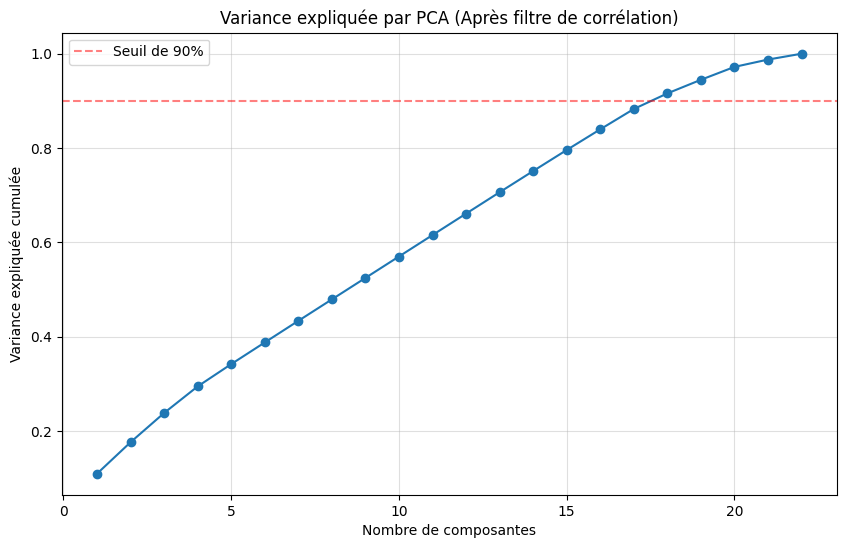

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features supprimées (corrélation > {threshold}) : {len(col_corr)}")
    print(col_corr)

    # CORRECTION : On applique VRAIMENT la réduction !
    df_reduced = X_train_df.drop(columns=col_corr)
    print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA
    # ---------------------------------------------------------
    scaler = StandardScaler()
    # CORRECTION : On fit le scaler sur df_reduced, pas sur X_train_df
    X_train_scale = scaler.fit_transform(df_reduced) 
    
    pca = PCA()
    pca.fit(X_train_scale)

    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%')
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## Matrix Correlation

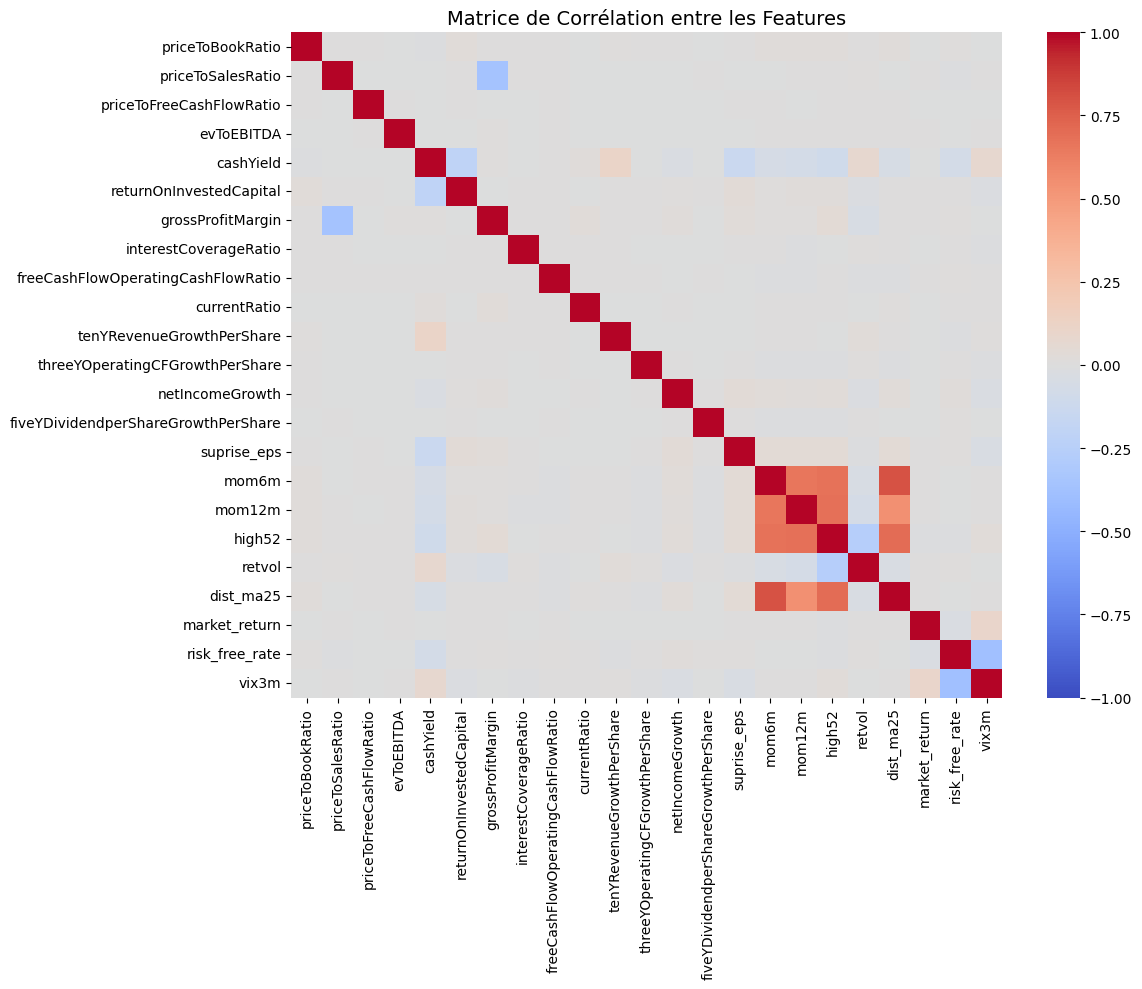


🔥 TOP 50 des paires de variables les plus corrélées :
mom6m                      dist_ma25                    0.801481
high52                     dist_ma25                    0.696287
                           mom12m                       0.685454
                           mom6m                        0.672636
mom12m                     mom6m                        0.656475
                           dist_ma25                    0.543738
risk_free_rate             vix3m                       -0.389080
priceToSalesRatio          grossProfitMargin           -0.360559
high52                     retvol                      -0.262576
cashYield                  returnOnInvestedCapital     -0.210158
suprise_eps                cashYield                   -0.137540
cashYield                  tenYRevenueGrowthPerShare    0.115963
high52                     cashYield                   -0.099293
market_return              vix3m                        0.098768
cashYield                  retvol  

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# VISUALISATION DE LA MATRICE DE CORRÉLATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 10)) # Taille ajustable selon le nombre de tes features

# Création de la heatmap
# vmin et vmax forcent l'échelle de -1 (rouge inverse) à 1 (bleu)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title("Matrice de Corrélation entre les Features", fontsize=14)
plt.tight_layout()
plt.show()

# Astuce bonus : Afficher le TOP 10 des paires les plus corrélées (en texte)
print("\n🔥 TOP 50 des paires de variables les plus corrélées :")
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
# On enlève la corrélation de 1.0 (une variable avec elle-même) et on enlève les doublons
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()
print(corr_pairs.head(50))

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [15]:
def calculate_mcc(y_true, y_pred):
    """
    Calcule le Matthews Correlation Coefficient (MCC) pour des classes déséquilibrées.
    
    y_true : array ou liste des vraies étiquettes (0 ou 1)
    y_pred : array ou liste des prédictions de l'IA (0 ou 1)
    """
    # Conversion en arrays numpy pour faciliter les calculs vectoriels
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Comptage physique de la matrice de confusion
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    # 2. Calcul du Numérateur (La différence croisée)
    numerator = (TP * TN) - (FP * FN)
    
    # 3. Calcul du Dénominateur (Produit des marges)
    # On ajoute un float( ) pour éviter un dépassement de capacité (overflow)
    denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
    
    # 4. Sécurité : Si le dénominateur est 0, le MCC est défini comme 0
    if denominator == 0:
        return 0.0
        
    return numerator / denominator


### Logistic Regression

In [16]:
def train_logistic_regression(X_train_scaled, y_train):
    with mlflow.start_run(run_name="Logistic Regression", nested=True):
        ols = LogisticRegression(class_weight='balanced')
        ols.fit(X_train_scaled, y_train)
        return ols

### XGBoost

In [17]:
def train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="XGBoost", nested=True):
        xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre,n_jobs=-1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
        return xgb_model

### LightGBM

In [18]:
def train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="LightGBM", nested=True):
        lgbm = lgb.LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre,n_jobs=-1, random_state=42)
        lgbm.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])
        return lgbm

### CatBoost

In [19]:
def train_catboost(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="CatBoost", nested=True):
        cb = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre, random_seed=42, verbose=False, thread_count=-1)
        cb.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), use_best_model=True)
        return cb

### Random Forest (GridSearchCV + MLflow Autolog)

In [20]:
def train_rf(X_train_scaled, y_train):
    with mlflow.start_run(run_name="RandomForestClassifier", nested=True):
        # On a retiré "scoring='roc_auc'"
        rf = RandomForestClassifier(
            n_estimators=500, 
            max_depth=10, 
            class_weight='balanced_subsample', 
            random_state=42,
            n_jobs=-1 # Petit bonus : ça force ton Mac à utiliser tous ses cœurs pour aller plus vite !
        )
        rf.fit(X_train_scaled, y_train)
        return rf

### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [21]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1, 'sigmoid'))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    total = neg + pos
    
    # Formule standard de Keras pour équilibrer parfaitement les gradients
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * (total / 2.0)
    class_weight_dict = {0: weight_for_0, 1: weight_for_1}
    
    print(f"Poids des classes : 0 -> {weight_for_0:.2f} | 1 -> {weight_for_1:.2f}") 
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective=kt.Objective('val_auc', direction='max'), # On cible val_auc vers le haut
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=patience, 
            restore_best_weights=True
        )
        
        # On passe le class_weight au Tuner pour qu'il cherche les meilleurs HP en tenant compte du déséquilibre
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, 
                     callbacks=[early_stopping], class_weight=class_weight_dict, verbose=0)
        
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
        
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)



## 5. Backtesting Portfolio Construction (Decile Sorting)

In [22]:
import pandas as pd
import numpy as np

def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    ENTRY/EXIT: Strictly holds the Top N performing stocks based on predictions_col.
    Rebalances every period based pure IA predictions.
    """
    results = []
    trades_dict = {} 
    
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calcul du rendement futur
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    test_df = test_df.dropna(subset=['return+1'])
    
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        # On s'assure d'avoir assez de données pour le benchmark, même si on est en cash
        if len(week_data) < 10: 
            continue
            
        week_data = week_data.copy()
        date_str = date.strftime('%Y-%m-%d')
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. GESTION DU PORTEFEUILLE (Pure IA) ---
        try:
            # On cherche les meilleures prédictions du moment (seuil à 0.1 selon ton code)
            valid_stocks = week_data[week_data[predictions_col] >= 0.1].copy()
            
            # On trie par la plus forte probabilité
            valid_stocks = valid_stocks.sort_values(by=predictions_col, ascending=False)
            
            # On sélectionne strictement le Top N
            long_portfolio = valid_stocks.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # Récupération des rendements
                gross_portfolio_return = long_portfolio['return+1'].mean()
                
                # Mise à jour du journal de trading
                trades_dict[date_str] = dict(zip(long_portfolio['symbol'], long_portfolio['return+1']))
                
                # --- 3. DYNAMIC TRANSACTION COSTS ---
                new_longs = curr_long_symbols - prev_long_symbols
                turnover_long = len(new_longs) / num_l 
                cost_long = turnover_long * transaction_cost * 2 # Frais sur le roulement uniquement
                net_portfolio_return = gross_portfolio_return - cost_long
                
                prev_long_symbols = curr_long_symbols
            else:
                # 100% Cash (L'IA ne trouve rien au-dessus de 0.1)
                trades_dict[date_str] = {'CASH': 0.0}
                gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
                prev_long_symbols = set()
                
        except Exception as e:
            print(f"❌ Erreur à la date {date} : {e}")
            trades_dict[date_str] = {'ERROR': 0.0}
            gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
            prev_long_symbols = set()
            
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}, trades_dict
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics, trades_dict

## 6. Run the Pipeline over the Expanding Window

In [23]:
if len(splits) > 0:

    print("🧹 Nettoyage des données avant l'entraînement...")
    df['ma26'] = df.groupby('symbol')['adjClose'].transform(lambda x: x.rolling(window=55).mean())
    df = df.replace([np.inf, -np.inf], np.nan)
    # On s'assure de ne pas avoir de NaN sur nos cibles
    #df = df.dropna(subset=['target_y'])
    df = df.dropna(subset=features)
    df = df.reset_index(drop=True)

    print(f"✅ Nettoyage terminé. Taille du dataset : {df.shape}")

    splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)
    
    print(f"🚀 Lancement du Backtest Classification sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 an fixe"
    NUM_SPLITS = 1
    TOP = 100
    POURCENTAGE=30

    NOTES = "TOP 100 1 an Pourcentage 50% Test final de Classification. Comparaison de 6 Modèles avec MCC. Avec Réduction de feature."

    mlflow.set_experiment("Maximize_CAGR_SP500_Classification")
    run_name = f"Test_{STRATEGY_FREQ}_MultiModels_Target{TARGET_FREQ}_Top{TOP}_Pourcentage{POURCENTAGE}"
    model_keys = ['dnn', 'rf', 'lr', 'xgboost', 'lightgbm', 'catboost']

    with mlflow.start_run(run_name="CAGR_Forward_Backtest_Multi_Classification") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "transaction_cost": TRANS_COST,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "pourcentage": POURCENTAGE,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # =========================================================
        # 1. LA BOUCLE SUR TOUTES LES ANNÉES
        # =========================================================
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            # 🛠️ CORRECTION : Utilisation de target_y pour l'entraînement
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)
            
            # --- ENTRAÎNEMENTS ---
            print("  -> Training DNN...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            
            print("  -> Training ML Models...")
            rf_model = train_rf(X_train_scaled, y_train)
            lr_model = train_logistic_regression(X_train_scaled, y_train)
            xgboost_model = train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val)
            lightgbm_model = train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val)
            catboost_model = train_catboost(X_train_scaled, y_train, X_val_scaled, y_val)
            
            # --- PRÉDICTIONS GROUPÉES ---
            preds_dict = {
                'dnn': predict_dnn_ensemble(dnn_models, scaler, X_test),
                'rf': rf_model.predict_proba(X_test_scaled)[:, 1],
                'lr': lr_model.predict_proba(X_test_scaled)[:, 1],
                'xgboost': xgboost_model.predict_proba(X_test_scaled)[:, 1],
                'lightgbm': lightgbm_model.predict_proba(X_test_scaled)[:, 1],
                'catboost': catboost_model.predict_proba(X_test_scaled)[:, 1]
            }
            
            test_df_year = df.loc[test_idx].copy()
            mcc_year_dict = {}
            
            # --- SUIVI ANNÉE PAR ANNÉE ---
            for model_name, preds_proba in preds_dict.items():
                preds_binary = (preds_proba >= 0.5).astype(int)
                mcc_year = float(calculate_mcc(y_test.values, preds_binary))
                mcc_year_dict[model_name] = mcc_year
                
                mlflow.log_metric(f"Yearly_{model_name.upper()}_MCC_OOS", mcc_year, step=int(test_year))
                test_df_year[f'{model_name}_pred'] = preds_proba
                
            # 🛠️ CORRECTION : Print propre avec les scores MCC
            print(f"  -> MCC {test_year} | DNN: {mcc_year_dict['dnn']:.4f} | XGB: {mcc_year_dict['xgboost']:.4f} | LGBM: {mcc_year_dict['lightgbm']:.4f}")
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 2. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul des Backtests...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        final_metrics = {}
        
        for model_name in model_keys:
            pred_col = f'{model_name}_pred'
            
            # 🛠️ CORRECTION : MCC Global au lieu du R2
            global_preds_binary = (final_test_df[pred_col].values >= 0.5).astype(int)
            mcc_global = float(calculate_mcc(final_test_df['target_y'].values, global_preds_binary))
            mlflow.log_metric(f"Global_{model_name.upper()}_MCC_OOS", mcc_global)
            
            # Backtest
            print(f"Running Backtest for {model_name.upper()}...")
            bt_df, metrics, dict_des_trades = backtest_portfolio(final_test_df, pred_col, transaction_cost=TRANS_COST, top_n=TOP)
            
            if not bt_df.empty:
                mlflow.log_metrics({f"{model_name.upper()}_{k}": float(v) for k, v in metrics.items()})
                final_metrics[model_name.upper()] = metrics
            else:
                print(f"  ⚠️ Backtest vide pour {model_name.upper()}.")

        # =========================================================
        # 3. AFFICHAGE DU TABLEAU COMPARATIF FINAL
        # =========================================================
        if final_metrics:
            metrics_table_data = {
                "Métrique": [
                    "Total Return", 
                    "CAGR (Annualisé)", 
                    "Sharpe Ratio", 
                    "Max Drawdown",
                    "Probabilité Overfitting"
                ]
            }
            
            first_model = list(final_metrics.keys())[0]
            metrics_table_data["S&P 500 (Benchmark)"] = [
                f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
                f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%",
                "N/A"
            ]

            for model_name, metrics in final_metrics.items():
                metrics_table_data[model_name] = [
                    f"{metrics['Total_Return']*100:.2f}%", 
                    f"{metrics['CAGR']*100:.2f}%", 
                    f"{metrics['Sharpe_Ratio']:.2f}", 
                    f"{metrics['Max_Drawdown']*100:.2f}%",
                    f"{metrics.get('Prob_Overfitting', 0)*100:.2f}%"
                ]
                
            metrics_table = pd.DataFrame(metrics_table_data)
            
            print("\n" + "="*120)
            print("📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)")
            print("="*120)
            print(metrics_table.to_string(index=False))
            print("="*120 + "\n")
            
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
else:
    print("Not enough data to form a split. Check your timeframe.")


🧹 Nettoyage des données avant l'entraînement...
✅ Nettoyage terminé. Taille du dataset : (547524, 168)
Total years in dataset: 1990 to 2026
Train ends before: 2012
Validation: 2012 to 2016
Test: 2017 to 2026
🚀 Lancement du Backtest Classification sur 1 années...

--- Traitement de l'Année de Test 2017 (1/1) ---
  -> Training DNN...
Poids des classes : 0 -> 0.59 | 1 -> 3.42


2026-03-21 12:38:06.395884: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-21 12:38:06.395917: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-21 12:38:06.395924: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1774093086.395936  119889 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774093086.395957  119889 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starting KerasTuner RandomSearch...
Best HPs found: Layer1: 32, Layer2: 32, LR: 0.01


2026-03-21 12:38:16.494767: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-21 12:38:16.509164: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-21 12:38:16.844446: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

Running Backtest for XGBOOST...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/4045215667.py:23: RuntimeWarning: overflow encountered in scalar multiply
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/4045215667.py:23: RuntimeWarning: invalid value encountered in sqrt
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))


Running Backtest for LIGHTGBM...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/4045215667.py:23: RuntimeWarning: overflow encountered in scalar multiply
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/4045215667.py:23: RuntimeWarning: invalid value encountered in sqrt
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))


Running Backtest for CATBOOST...

📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)
               Métrique S&P 500 (Benchmark)     DNN      RF      LR XGBOOST LIGHTGBM CATBOOST
           Total Return             305.50% 132.33% 175.69% 165.79% 201.95%  193.56%  176.14%
       CAGR (Annualisé)              15.03%   8.80%  10.67%  10.27%  11.68%   11.37%   10.69%
           Sharpe Ratio                0.84    0.46    0.57    0.52    0.62     0.60     0.56
           Max Drawdown             -33.12% -52.55% -44.72% -49.70% -41.46%  -42.38%  -45.11%
Probabilité Overfitting                 N/A   0.00%   0.00%   0.00%   0.00%    0.00%    0.00%



## 7. Visualisation results

🚀 Lancement des backtests pour tous les modèles...
  -> Backtest en cours pour DNN...
  -> Backtest en cours pour Random Forest...
  ❌ Colonne ols_pred introuvable. Modèle ignoré.
  ❌ Colonne lasso_pred introuvable. Modèle ignoré.
  ❌ Colonne ridge_pred introuvable. Modèle ignoré.
  -> Backtest en cours pour XGBoost...
  -> Backtest en cours pour LightGBM...
  -> Backtest en cours pour CatBoost...

📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)
        Métrique S&P 500 (Benchmark)     DNN Random Forest XGBoost LightGBM CatBoost
    Total Return             305.50% 156.01%       139.24% 119.42%  195.75%  159.91%
CAGR (Annualisé)              15.03%   9.86%         9.11%   8.18%   11.45%   10.02%
    Sharpe Ratio                0.84    0.49          0.45    0.44     0.53     0.48
    Max Drawdown             -33.12% -47.49%       -52.56% -55.09%  -53.68%  -53.33%



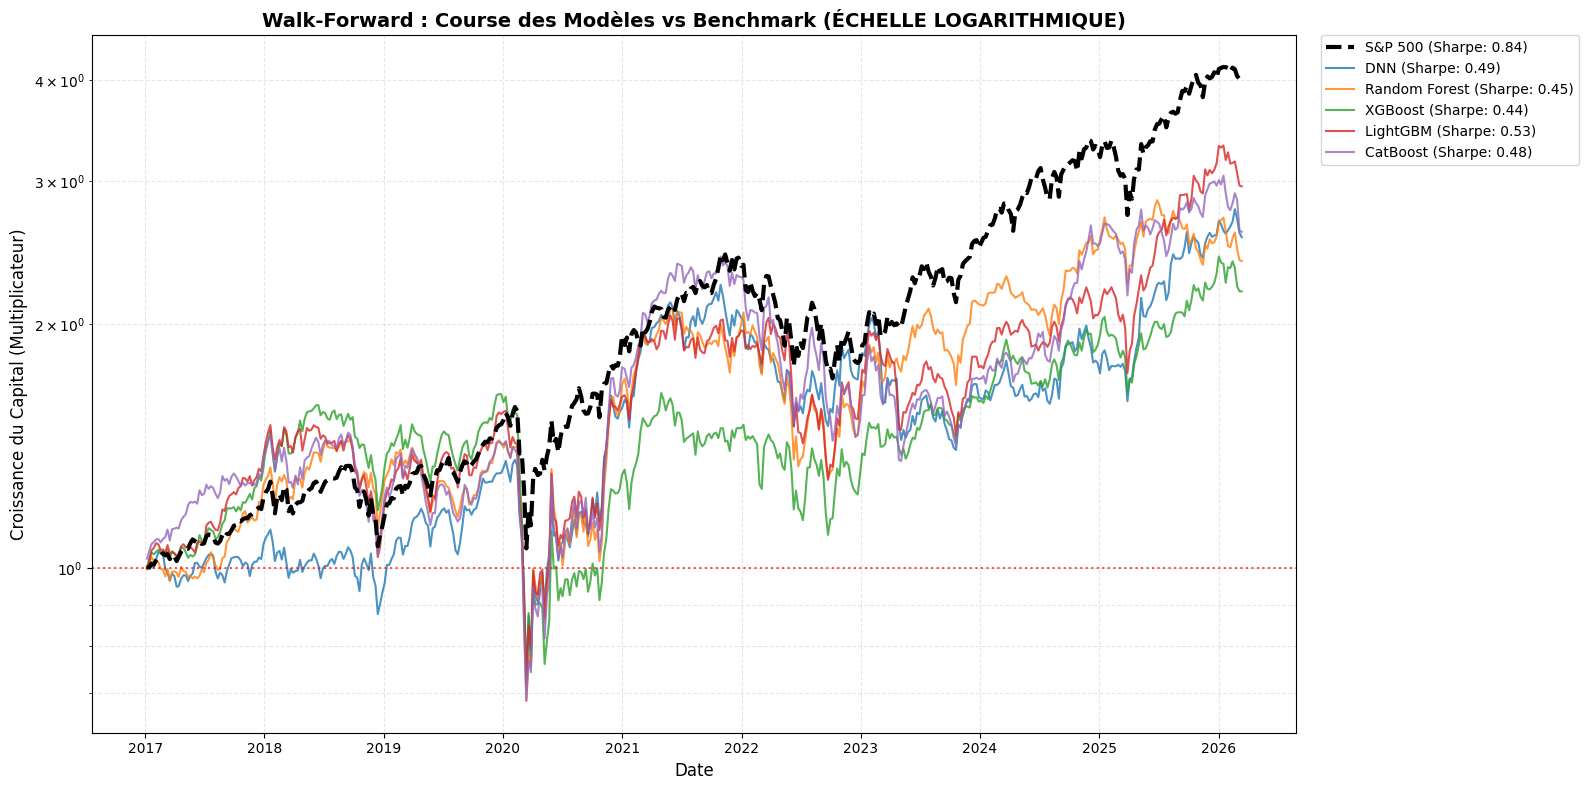

26/03/21 16:46:30 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 Lancement des backtests pour tous les modèles...")

# 1. On liste tous les modèles et leurs colonnes de prédictions correspondantes
models_to_test = {
    'DNN': 'dnn_pred',
    'Random Forest': 'rf_pred',
    'OLS': 'ols_pred',
    'Lasso': 'lasso_pred',
    'Ridge': 'ridge_pred',
    'XGBoost': 'xgboost_pred',
    'LightGBM': 'lightgbm_pred',
    'CatBoost': 'catboost_pred'
}

# On initialise nos fameux dictionnaires !
all_bt_df = {}
final_metrics = {}

# 2. On boucle pour calculer le backtest de chaque modèle
for model_name, pred_col in models_to_test.items():
    # On vérifie par sécurité que la colonne existe bien dans final_test_df
    if pred_col in final_test_df.columns:
        print(f"  -> Backtest en cours pour {model_name}...")
        bt_df, metrics, dict_des_trades= backtest_portfolio(final_test_df, pred_col, transaction_cost=0.001, top_n=10)
        
        # Si le backtest a fonctionné, on le stocke
        if not bt_df.empty:
            all_bt_df[model_name] = bt_df
            final_metrics[model_name] = metrics
        else:
            print(f"  ⚠️ Le backtest pour {model_name} est vide.")
    else:
        print(f"  ❌ Colonne {pred_col} introuvable. Modèle ignoré.")

# Si on a au moins un modèle réussi, on passe à l'affichage
if final_metrics:
    
    # ==========================================
    # 3. TABLEAU DES PERFORMANCES MULTI-MODÈLES
    # ==========================================
    metrics_table_data = {
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"]
    }
    
    # Ajout du Benchmark (S&P 500) en premier
    first_model = list(final_metrics.keys())[0]
    metrics_table_data["S&P 500 (Benchmark)"] = [
        f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
        f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%"
    ]

    # Ajout de tous les modèles
    for model_name, metrics in final_metrics.items():
        metrics_table_data[model_name] = [
            f"{metrics['Total_Return']*100:.2f}%", 
            f"{metrics['CAGR']*100:.2f}%", 
            f"{metrics['Sharpe_Ratio']:.2f}", 
            f"{metrics['Max_Drawdown']*100:.2f}%"
        ]
        
    metrics_table = pd.DataFrame(metrics_table_data)
    
    print("\n" + "="*120)
    print("📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)")
    print("="*120)
    print(metrics_table.to_string(index=False))
    print("="*120 + "\n")

    # ==========================================
    # 4. GRAPHIQUE MULTI-COURBES (ÉCHELLE LOG)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # On trace la courbe du S&P 500 (Benchmark) en noir épais
    first_bt = list(all_bt_df.values())[0]
    bench_sharpe = final_metrics[first_model]['Bench_Sharpe']
    ax1.plot(first_bt['date'], first_bt['cum_benchmark'], label=f"S&P 500 (Sharpe: {bench_sharpe:.2f})", color='black', linestyle='--', linewidth=3, zorder=10)

    # On trace les courbes de tous les modèles IA
    for model_name, bt_data in all_bt_df.items():
        sharpe = final_metrics[model_name]['Sharpe_Ratio']
        # Les modèles avec un bon Sharpe auront tendance à se démarquer visuellement
        ax1.plot(bt_data['date'], bt_data['cum_return'], label=f"{model_name} (Sharpe: {sharpe:.2f})", linewidth=1.5, alpha=0.8)

    # Ligne de base (Capital de départ)
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.7)
    
    # Paramètres d'affichage
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward : Course des Modèles vs Benchmark (ÉCHELLE LOGARITHMIQUE)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Croissance du Capital (Multiplicateur)', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    
    # On met la légende à l'extérieur pour ne pas cacher les courbes
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., fontsize=10) 
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Tous les backtests ont échoué ou sont vides.")
          

In [25]:
top_n = 10
transactio_cost = 0.001
pred_col = "rf_pred"
bt_df, metrics, dict_des_trades = backtest_portfolio(final_test_df, pred_col, transaction_cost=transactio_cost, top_n=top_n)
dict_des_trades

{'2017-01-06': {'ATI': 0.020522388059701635,
  'BBBY': 0.0,
  'SPLS': 0.002185792349726823,
  'EQT': -0.0483772198407838,
  'DVN': -0.04650482597250649,
  'FCX': 0.020044543429843964,
  'BIIB': -0.03474576271186436,
  'SB': 0.05660377358490565,
  'CNC': 0.026539973787680138,
  'MRO': -0.0243293824079851},
 '2017-01-13': {'ATI': 0.03960999390615472,
  'BBBY': -0.04692082111436957,
  'EQT': 0.011261261261261257,
  'SPLS': -0.0010905125408942062,
  'BIIB': -0.014363476733977087,
  'PSX': -0.0030732456889192017,
  'DVN': -0.0033742331288343363,
  'SB': 0.16964285714285698,
  'FCX': 0.021106259097525504,
  'COP': 0.002905441098784989},
 '2017-01-20': {'ATI': 0.27960140679953116,
  'SPLS': 0.0,
  'BBBY': 0.04923076923076919,
  'SB': -0.11450381679389321,
  'WFM': -0.016228497241155493,
  'REGN': -0.044317329853108545,
  'BIIB': -0.008729423501745992,
  'CRM': 0.02862087326943552,
  'EQT': 0.02099904549793208,
  'FE': -0.0014669926650365817},
 '2017-01-27': {'ATI': -0.008245533669262506,
  'W

⚡ Calcul des SHAP sur un échantillon (Version Rapide)...


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/414121533.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features, max_display=len(features))


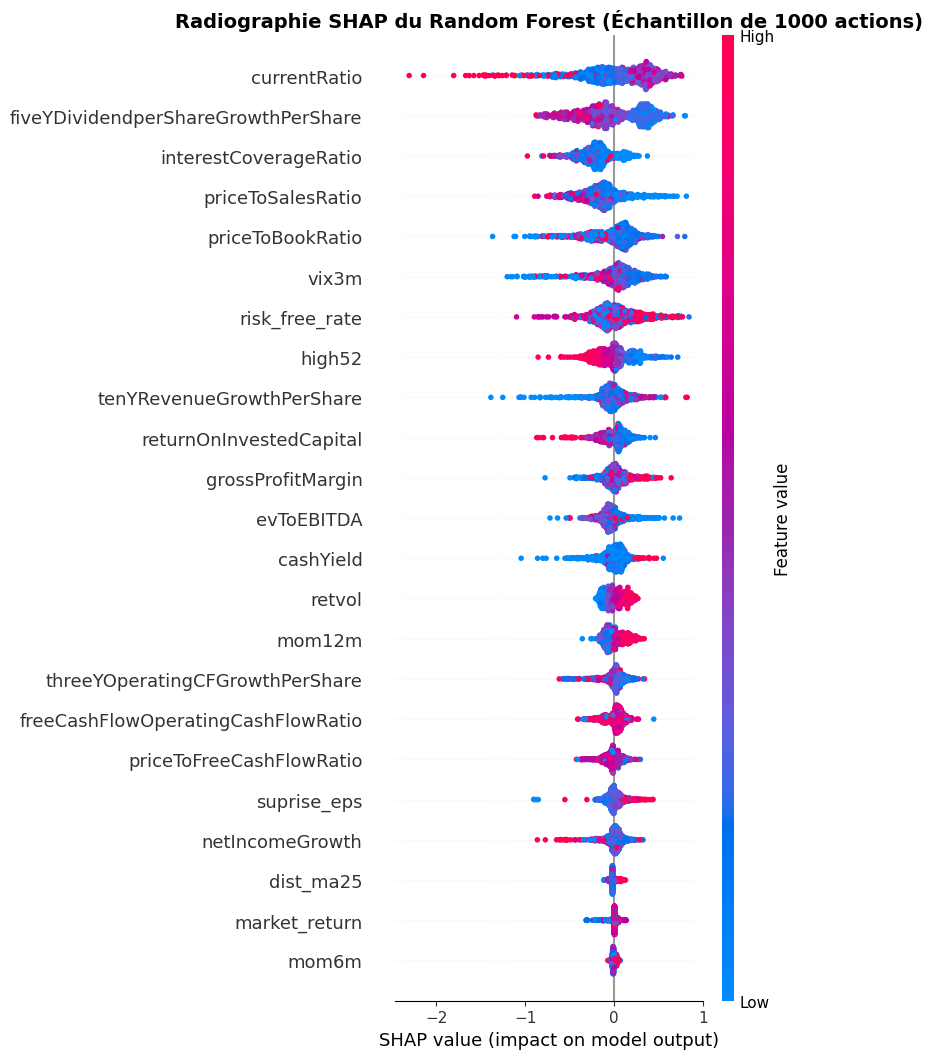

In [26]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚡ Calcul des SHAP sur un échantillon (Version Rapide)...")

# 1. LA MAGIE : On prend un échantillon de 1000 lignes au hasard
taille_echantillon = min(1000, X_test_scaled.shape[0])
indices_aleatoires = np.random.choice(X_test_scaled.shape[0], size=taille_echantillon, replace=False)
X_test_sample = X_test_scaled[indices_aleatoires]

# 2. On recrée l'explainer
explainer_rf = shap.TreeExplainer(lightgbm_model)

# 3. On calcule UNIQUEMENT sur l'échantillon (Ça va prendre 5 secondes au lieu de 20 minutes !)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# 4. Formatage de la sortie (identique à avant)
if isinstance(shap_values_rf, list):
    shap_vals_rf_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    shap_vals_rf_to_plot = shap_values_rf[:, :, 1]
else:
    shap_vals_rf_to_plot = shap_values_rf

# 5. Affichage
plt.figure(figsize=(10, 8))
plt.title("Radiographie SHAP du Random Forest (Échantillon de 1000 actions)", fontsize=14, fontweight='bold')
# Attention : on donne bien X_test_sample au graphique pour que les couleurs correspondent !
shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features, max_display=len(features))

⚡ Calcul des SHAP sur un échantillon (Version Rapide)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_5386/504590105.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features, max_display=len(features))


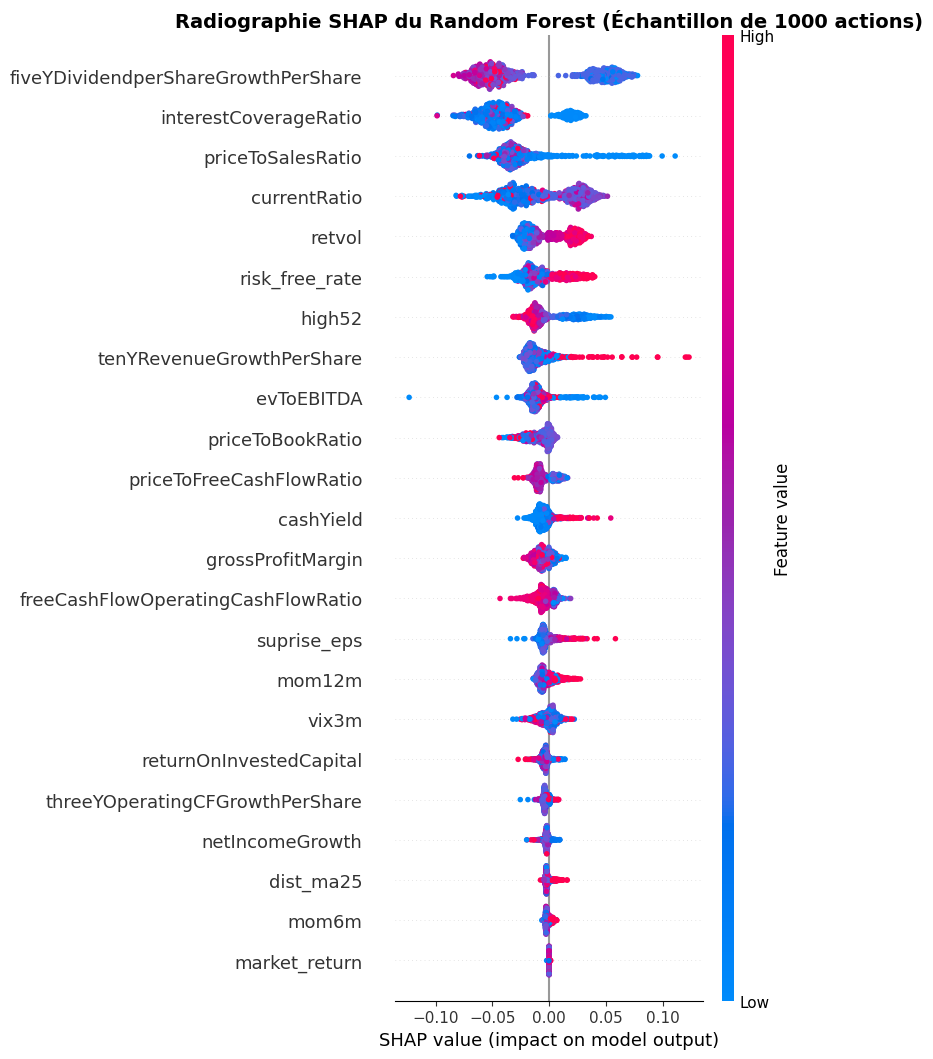

In [27]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚡ Calcul des SHAP sur un échantillon (Version Rapide)...")

# 1. LA MAGIE : On prend un échantillon de 1000 lignes au hasard
taille_echantillon = min(1000, X_test_scaled.shape[0])
indices_aleatoires = np.random.choice(X_test_scaled.shape[0], size=taille_echantillon, replace=False)
X_test_sample = X_test_scaled[indices_aleatoires]

# 2. On recrée l'explainer
explainer_rf = shap.TreeExplainer(rf_model)

# 3. On calcule UNIQUEMENT sur l'échantillon (Ça va prendre 5 secondes au lieu de 20 minutes !)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# 4. Formatage de la sortie (identique à avant)
if isinstance(shap_values_rf, list):
    shap_vals_rf_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    shap_vals_rf_to_plot = shap_values_rf[:, :, 1]
else:
    shap_vals_rf_to_plot = shap_values_rf

# 5. Affichage
plt.figure(figsize=(10, 8))
plt.title("Radiographie SHAP du Random Forest (Échantillon de 1000 actions)", fontsize=14, fontweight='bold')
# Attention : on donne bien X_test_sample au graphique pour que les couleurs correspondent !
shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features, max_display=len(features))

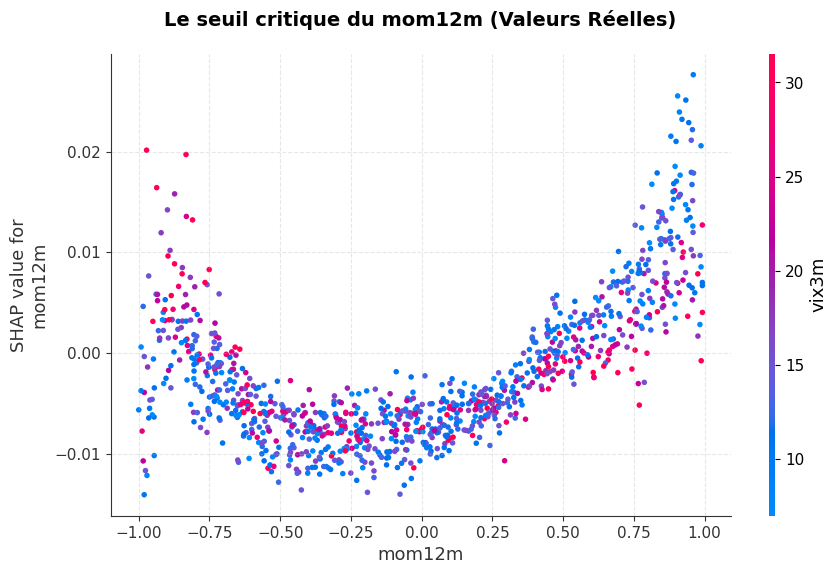

In [28]:
# 1. On récupère exactement les mêmes 1000 lignes, mais sur les données NON-SCALÉES
# (Assure-toi que "X_test" est bien ton DataFrame d'origine avec le nom des colonnes)
X_test_unscaled_sample = X_test.iloc[indices_aleatoires]

# 2. On trace le graphique en mélangeant les deux !
shap.dependence_plot(
    "mom12m", 
    shap_vals_rf_to_plot,          # Les valeurs SHAP calculées par le modèle (qui a utilisé le Scaler)
    X_test_unscaled_sample,        # 🚀 LA MAGIE : Les vraies valeurs financières pour l'axe X
    interaction_index="auto",
    show=False
)

import matplotlib.pyplot as plt
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.title("Le seuil critique du mom12m (Valeurs Réelles)", fontsize=14, fontweight='bold', pad=20)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [29]:
df_all_oos_results = pd.DataFrame(all_oos_results[0])
df_all_oos_results['date'].max()

Timestamp('2026-03-18 00:00:00')

In [30]:
final_test_df['date'].min()

Timestamp('2017-01-04 00:00:00')

In [31]:
top_10_per_date = final_test_df.sort_values(by=['date', 'catboost_pred'], ascending=[True, False])

# 2. On groupe par date et on ne garde que les 10 premières lignes de chaque groupe
top_10_per_date = top_10_per_date.groupby('date').head(5)

# 3. On affiche un aperçu épuré (Date, Action, Score IA, et le vrai résultat pour comparer)
colonnes_a_afficher = ['date', 'symbol', 'catboost_pred', 'target_y']
print(top_10_per_date[colonnes_a_afficher].tail(20))

             date symbol  catboost_pred  target_y
545587 2026-02-27    CNC       0.711447         0
545947 2026-02-27    MOH       0.708389         0
546039 2026-02-27      F       0.681125         0
545704 2026-02-27   PSKY       0.667653         0
545638 2026-02-27    HUM       0.661077         0
546484 2026-03-06    CNC       0.714557         0
546099 2026-03-06    MOH       0.708389         0
546285 2026-03-06      F       0.697496         0
546211 2026-03-06   PSKY       0.667334         0
546460 2026-03-06   TSLA       0.666789         0
546995 2026-03-13    CNC       0.712298         0
546770 2026-03-13    MOH       0.708389         0
546872 2026-03-13   PSKY       0.667334         0
546562 2026-03-13      F       0.660111         0
546732 2026-03-13   TSLA       0.652769         0
547146 2026-03-18    MOH       0.702884         0
547211 2026-03-18    CNC       0.701433         0
547510 2026-03-18      F       0.672187         0
547413 2026-03-18   TSLA       0.651221         0


In [32]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,month,week,target_y,ma26,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred
465548,BSX,2023-01-06,46.33,8980864,0.022841,0.000185,-0.575049,-0.863548,-0.629630,-0.247563,...,1,4,1,42.002000,0.354692,0.386014,0.363012,0.202079,0.256545,0.416026
465636,NFLX,2023-01-06,31.55,89598390,0.022841,0.000185,0.220273,0.789474,-0.972710,-0.298246,...,1,4,1,NaN,0.496719,0.482099,0.750411,0.451631,0.458608,0.568910
465474,HWM,2023-01-06,40.05,2511500,0.022841,0.000185,-0.267057,0.009747,0.368421,0.122807,...,1,4,1,34.628182,0.366065,0.460391,0.427917,0.287335,0.188749,0.475338
465466,RL,2023-01-06,109.94,534300,0.022841,0.000185,-0.625731,0.520468,0.723197,-0.910331,...,1,4,1,96.619091,0.380957,0.354152,0.533102,0.294633,0.242366,0.402708
465217,FOX,2023-01-06,28.38,1127315,0.022841,0.000185,0.368421,0.461988,0.968811,0.516569,...,1,4,1,NaN,0.510455,0.399171,0.557204,0.228942,0.325140,0.520658
465299,ETR,2023-01-06,47.86,3561662,0.022841,0.000185,0.879142,0.575049,0.360624,0.957115,...,1,4,1,49.351273,0.464033,0.302718,0.507648,0.229308,0.212229,0.357742
465652,AVGO,2023-01-06,56.25,35261010,0.022841,0.000185,0.734893,0.890838,-0.859649,0.855750,...,1,4,1,51.189636,0.394886,0.433489,0.526614,0.314895,0.238444,0.520278
465336,NRG,2023-01-06,29.69,3177447,0.022841,0.000185,-0.828460,-0.805068,-0.056530,-0.500975,...,1,4,1,36.059455,0.546472,0.355611,0.493694,0.154144,0.050694,0.637725
465437,UAL,2023-01-06,42.24,7728171,0.022841,0.000185,0.754386,0.937622,0.099415,-0.738791,...,1,4,1,41.269091,0.476768,0.556202,0.680545,0.478552,0.592120,0.581073
465534,AXP,2023-01-06,144.85,3077593,0.022841,0.000185,0.274854,-0.270955,-0.461988,0.563353,...,1,4,1,153.732182,0.477901,0.253648,0.567713,0.335901,0.387384,0.349783


In [33]:
df_test_decile = final_test_df.copy()

In [34]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,week,target_y,ma26,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred,decile
count,225861,225861.000000,2.258610e+05,225861.000000,225861.000000,225861.000000,225861.000000,225861.000000,225861.000000,225861.000000,...,225861.000000,225861.000000,216758.000000,225861.000000,225861.000000,2.258610e+05,225861.000000,225861.000000,225861.000000,225861.000000
mean,2021-09-20 20:39:06.668083712,142.350248,6.644613e+06,0.000803,0.000101,-0.011388,-0.007871,-0.024173,-0.005317,0.001101,...,3.965913,0.086026,133.587970,0.432349,0.337796,4.750795e-01,0.212755,0.237067,0.399353,32.999987
min,2017-01-04 00:00:00,0.333600,6.000000e+02,-0.059746,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,0.000000,0.000000,0.874746,0.291263,0.110967,2.896742e-21,0.000280,0.001078,0.107105,1.000000
25%,2019-06-14 00:00:00,43.740000,1.103500e+06,-0.003672,0.000030,-0.510934,-0.506958,-0.521401,-0.504132,-0.497006,...,4.000000,0.000000,42.403864,0.399109,0.256233,3.954563e-01,0.078942,0.105337,0.319038,17.000000
50%,2021-10-15 00:00:00,82.250000,2.293211e+06,0.001114,0.000085,-0.017544,-0.011628,-0.029354,-0.007937,0.001957,...,4.000000,0.000000,78.127364,0.429023,0.328615,4.701550e-01,0.170503,0.200701,0.390517,33.000000
75%,2024-01-12 00:00:00,154.940000,5.190900e+06,0.006733,0.000173,0.485597,0.489279,0.469231,0.492843,0.499022,...,4.000000,0.000000,145.690182,0.463678,0.415696,5.500570e-01,0.307327,0.335831,0.474520,49.000000
max,2026-03-18 00:00:00,9924.400000,3.692928e+09,0.092871,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,4.000000,1.000000,8289.717818,0.956824,0.766463,1.000000e+00,0.972742,0.954109,0.774472,65.000000
std,NaN,310.506017,2.839468e+07,0.011440,0.000078,0.576914,0.576516,0.571791,0.576529,0.576168,...,0.196878,0.280404,289.094239,0.048809,0.101640,1.094931e-01,0.168108,0.166277,0.105677,18.761781


In [35]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.0

In [36]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.05496402877697842

In [37]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,week,target_y,ma26,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred,decile
547146,MOH,2026-03-18,148.63,1323404,-0.013605,0.000148,0.803468,0.799615,0.788054,-0.992293,...,2,0,214.652545,0.554074,0.555848,6.819300e-01,0.059990,0.119052,0.702884,65
547157,TJX,2026-03-18,152.87,3103525,-0.013605,0.000148,-0.533719,-0.657033,-0.587669,-0.109827,...,2,0,137.899091,0.586122,0.243163,3.656596e-13,0.067210,0.044478,0.335405,65
547166,REG,2026-03-18,76.40,1137577,-0.013605,0.000148,-0.344894,-0.152216,0.799615,0.032755,...,2,0,69.997273,0.597066,0.359039,9.270238e-19,0.044504,0.134292,0.362776,65
547289,AMP,2026-03-18,432.54,701848,-0.013605,0.000148,-0.884393,-0.865125,-0.329480,-0.606936,...,2,0,487.728182,0.619502,0.244014,4.963583e-01,0.006186,0.010408,0.374192,65
547179,MTD,2026-03-18,1191.54,138379,-0.013605,0.000148,0.248555,0.495183,0.533719,0.541426,...,2,0,1272.936909,0.631469,0.342835,4.591948e-01,0.040534,0.105738,0.390257,65
547233,CEG,2026-03-18,317.22,2634656,-0.013605,0.000148,-0.229287,0.776493,-0.360308,-0.942197,...,2,0,306.324545,0.557001,0.423903,4.195577e-01,0.111913,0.177611,0.483160,65
547445,VRSN,2026-03-18,238.89,634774,-0.013605,0.000148,-0.221580,-0.094412,0.522158,0.144509,...,2,0,257.400000,0.753140,0.292888,9.863034e-01,0.014755,0.034206,0.381495,65
546608,MTD,2026-03-13,1173.74,247708,-0.006056,0.000148,0.768786,0.749518,0.610790,0.907514,...,4,0,1274.412909,0.636899,0.348215,5.132179e-01,0.114336,0.201170,0.404277,65
546910,CEG,2026-03-13,301.77,1988620,-0.006056,0.000148,0.664740,0.078998,-0.533719,-0.448940,...,4,0,305.080727,0.588546,0.461142,5.346918e-01,0.275827,0.286828,0.530241,65
546791,TJX,2026-03-13,155.43,3123589,-0.006056,0.000148,-0.703276,-0.310212,-0.684008,-0.240848,...,4,0,137.360545,0.585713,0.246611,3.517792e-13,0.131443,0.098640,0.341369,65
